In [85]:
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv
# from langchain_google_genai import ChatGoogleGenerativeAI
from typing import TypedDict, Literal

In [86]:
load_dotenv()

True

In [87]:
# State Definition
class QuadraticEquationState(TypedDict):
    a: float
    b: float
    c: float

    discriminant: float
    eq_structure: str
    result: Literal["real_roots", "repeated_root", "No_real_roots"]
    

In [88]:
# model = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0.2)


In [89]:
graph = StateGraph(QuadraticEquationState)

In [90]:
def show_equation(state: QuadraticEquationState):
    a, b, c = state["a"], state["b"], state["c"]
    equation = f"{a}x^2 + {b}x + {c} = 0"
    return {"eq_structure": equation}

def calculate_discriminant(state: QuadraticEquationState):
    a, b, c = state["a"], state["b"], state["c"]
    discriminant = b**2 - 4*a*c
    return {"discriminant": discriminant}

def real_roots(state: QuadraticEquationState):
    a, b, c = state["a"], state["b"], state["c"]
    discriminant = state["discriminant"]
    root1 = (-b + discriminant**0.5) / (2*a)
    root2 = (-b - discriminant**0.5) / (2*a)
    return {"result": (root1, root2)}

def repeated_root(state: QuadraticEquationState):
    a, b, c = state["a"], state["b"], state["c"]
    root = -b / (2*a)
    return {"result": root}

def No_real_roots(state: QuadraticEquationState):
    return {"result": "The equation has no real roots."}    

def check_condition(state: QuadraticEquationState) -> Literal["real_roots", "repeated_root", "No_real_roots"]:
    discriminant = state["discriminant"]
    if discriminant > 0:
        return "real_roots"
    elif discriminant == 0:
        return "repeated_root"
    else:
        return "No_real_roots"

In [91]:
# Add Nodes
graph.add_node("show_equation", show_equation)
graph.add_node("calculate_discriminant", calculate_discriminant)
graph.add_node("real_roots", real_roots)
graph.add_node("No_real_roots", No_real_roots)
graph.add_node("repeated_root", repeated_root)


In [92]:
# Add Edges
graph.add_edge(START, "show_equation")
graph.add_edge("show_equation", "calculate_discriminant")
graph.add_conditional_edges("calculate_discriminant", check_condition)
graph.add_edge("real_roots", END)
graph.add_edge("repeated_root", END)
graph.add_edge("No_real_roots", END)

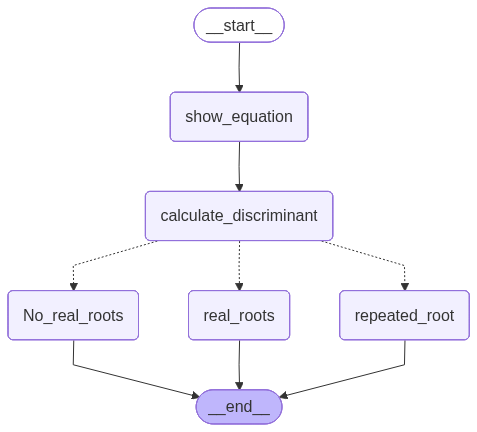

In [93]:
workflow = graph.compile()
workflow

In [95]:
initial_state = {
    "a": 1,
    "b": 4,
    "c": 1
}

final_state = workflow.invoke(initial_state)
print(final_state)

{'a': 1, 'b': 4, 'c': 1, 'discriminant': 12, 'eq_structure': '1x^2 + 4x + 1 = 0', 'result': (-0.2679491924311228, -3.732050807568877)}
